In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import style
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [18]:
df = pd.read_csv('winequalityN.csv')
print(df.head())

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1       0.49      9.5        6  
2       0.4

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6487.0,7.216579,1.296750,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6489.0,0.339691,0.164649,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6494.0,0.318722,0.145265,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6495.0,5.444326,4.758125,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6495.0,0.056042,0.035036,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6488.0,3.218395,0.160748,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6493.0,0.531215,0.148814,0.22000,0.43000,0.51000,0.60000,2.00000


In [21]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [22]:
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

np.int64(0)

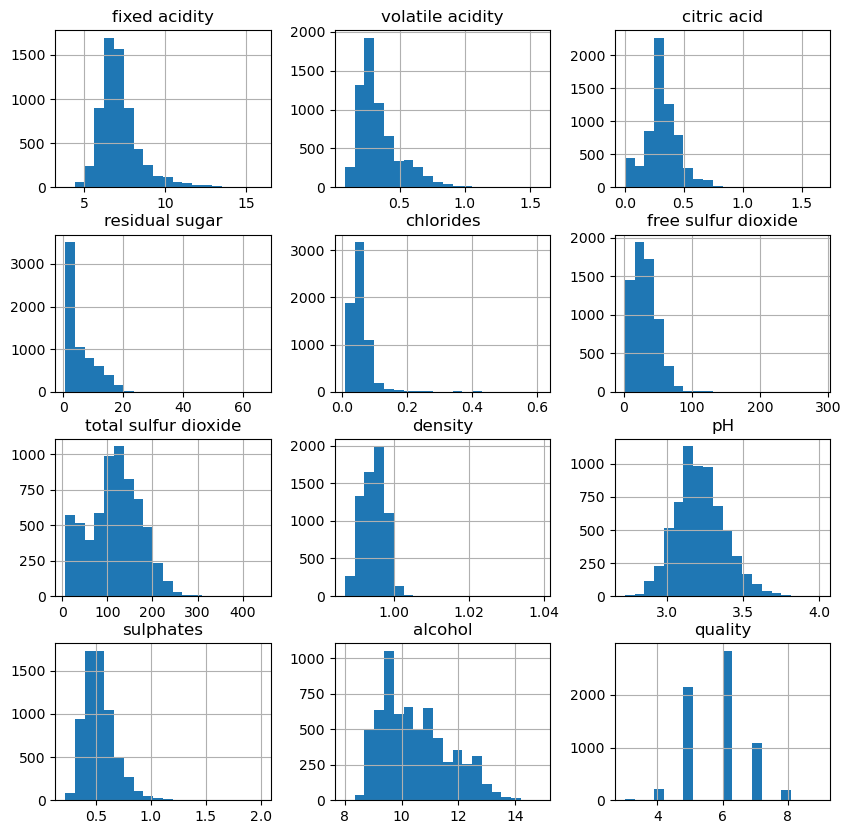

In [23]:
df.hist(bins=20, figsize=(10, 10))
plt.show()

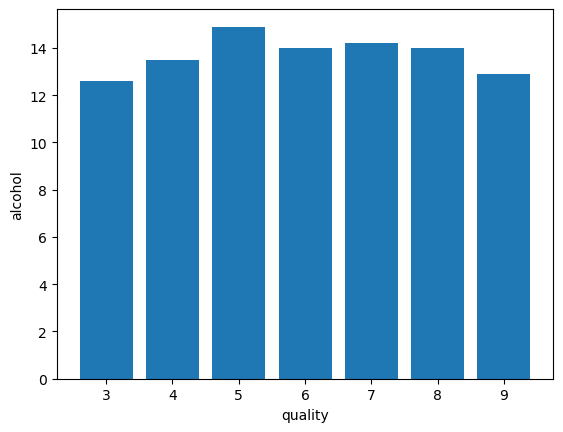

In [24]:
plt.bar(df['quality'], df['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

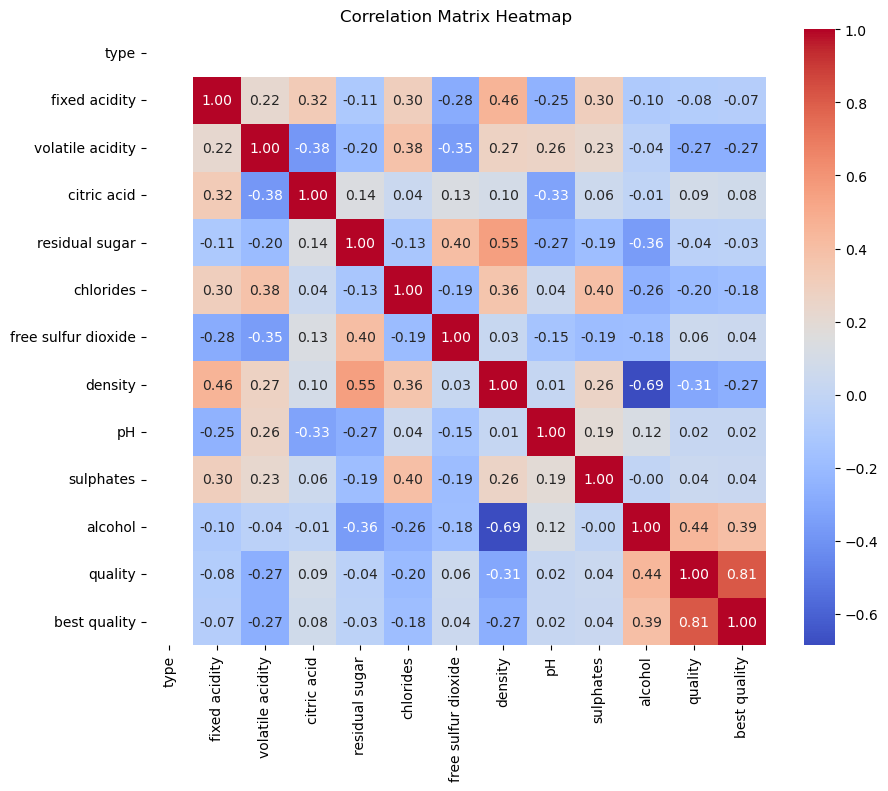

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 0 non-null      float64
 1   fixed acidity        6497 non-null   float64
 2   volatile acidity     6497 non-null   float64
 3   citric acid          6497 non-null   float64
 4   residual sugar       6497 non-null   float64
 5   chlorides            6497 non-null   float64
 6   free sulfur dioxide  6497 non-null   float64
 7   density              6497 non-null   float64
 8   pH                   6497 non-null   float64
 9   sulphates            6497 non-null   float64
 10  alcohol              6497 non-null   float64
 11  quality              6497 non-null   int64  
 12  best quality         6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [27]:
df['best quality'] = [1 if x > 5 else 0 for x in df.quality]

In [59]:
features = df.drop(['quality', 'best quality'], axis=1)
target = df['best quality']

xtrain, xtest, ytrain, ytest = train_test_split(
	features, target, test_size=0.1, random_state=30)

xtrain.shape, xtest.shape

((5847, 11), (650, 11))

In [60]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [61]:
#model training
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import metrics

# Create an imputer to handle NaN values
imputer = SimpleImputer(strategy='mean')  # You can choose 'mean', 'median', 'most_frequent', or 'constant'

# Apply the imputer to your training and test data
xtrain_imputed = imputer.fit_transform(xtrain)
xtest_imputed = imputer.transform(xtest)

# model training with imputed data
models = [LogisticRegression(), SVC(kernel='rbf')]

for i in range(2):
    models[i].fit(xtrain_imputed, ytrain)
    
    print(f'{models[i]} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(ytrain, models[i].predict(xtrain_imputed)))
    print('Validation Accuracy : ', metrics.roc_auc_score(
        ytest, models[i].predict(xtest_imputed)))
    print()

LogisticRegression() : 
Training Accuracy :  0.6979148112352658
Validation Accuracy :  0.7102187343463016

SVC() : 
Training Accuracy :  0.7290335518942548
Validation Accuracy :  0.7178890465854066



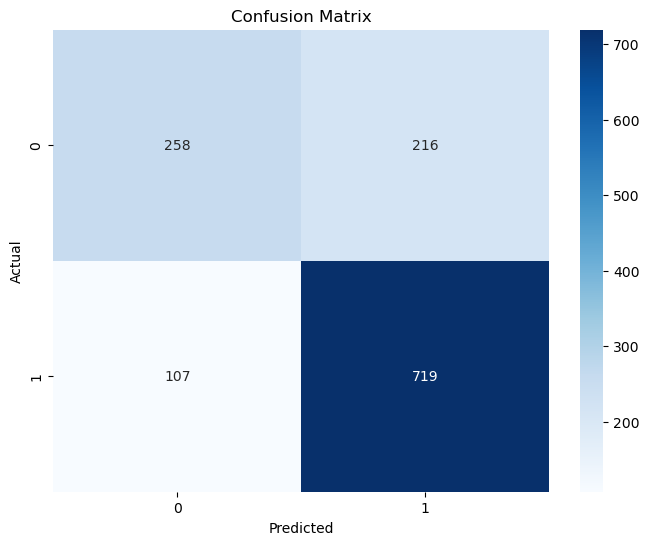

In [41]:
#Creating Confusion Matrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer

# Handle missing values in xtest using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # You can choose 'mean', 'median', 'most_frequent', or 'constant'
xtest_imputed = imputer.fit_transform(xtest)

# Generate the confusion matrix with imputed data
y_pred = models[1].predict(xtest_imputed)
cm = confusion_matrix(ytest, y_pred)

# Plot using seaborn for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=models[1].classes_, 
            yticklabels=models[1].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [64]:
# Example for LogisticRegression
from sklearn.linear_model import LogisticRegression  # Import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

# Create sample data for X_train and y_train
# In a real scenario, you would load your actual training data
X_train = np.random.rand(100, 10)  # 100 samples, 10 features
y_train = np.random.randint(0, 2, 100)  # Binary classification targets

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [65]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
# Classification Report

# Option 1: Use an imputer to replace NaN values with the mean
imputer = SimpleImputer(strategy='mean')  # You can also use 'median', 'most_frequent', or 'constant'
xtest_imputed = imputer.fit_transform(xtest)

# Classification Report with imputed data
print(metrics.classification_report(ytest, models[1].predict(xtest_imputed)))




              precision    recall  f1-score   support

           0       0.68      0.58      0.63       226
           1       0.79      0.86      0.82       424

    accuracy                           0.76       650
   macro avg       0.74      0.72      0.72       650
weighted avg       0.75      0.76      0.75       650



In [67]:


sample_to_predict = [[7.8, 0.49, 0.04, 2.3, 0.092, 15, 54, 0.997, 3.26, 0.61]]  # Now has 10 features

for model in models:
    predicted_quality = model.predict(sample_to_predict)
    print(f'Predicted quality using {model}:', predicted_quality)

Predicted quality using LogisticRegression(): [1]
Predicted quality using SVC(): [0]


In [68]:
sample_to_predict = [[7.8, 0.58, 0.02, 2, 0.073, 9, 18, 0.9968, 3.36, 0.52]]

for model in models:
    predicted_quality = model.predict(sample_to_predict)
    print(f'Predicted quality using {model}:', predicted_quality)

Predicted quality using LogisticRegression(): [1]
Predicted quality using SVC(): [0]
